In [11]:
import os
import pandas as pd
import h5py as h5
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np

In [12]:
def plot_f1_scores(csv_path, title, architectures=None, save_path=None):
    """
    Read a CSV file and plot F1-score trajectories with uncertainty bands.

    Args:
        csv_path (str): Path to the CSV file.
        title (str): Title for the plot.
        architectures (Iterable[str] | None): Optional iterable of architecture names
            (e.g. {"ATAT", "DiT", "DiViT-L"}) to include in the plot.
        save_path (str | None): Optional path to save the generated figure. When None the plot is not saved.
    """
    data = pd.read_csv(csv_path)
    mean_df = pd.concat([data.iloc[:, [0]], data.iloc[:, 1::2]], axis=1)
    std_df = data.iloc[:, ::2]
    mean_df.columns = [col.replace('_mean', '') for col in mean_df.columns]
    std_df.columns = [col.replace('_std', '') for col in std_df.columns]

    raw_names = mean_df['experiment_name'].astype(str)
    simclr_mask = ~raw_names.str.contains('simclr', case=False, na=False)
    windows_mask = ~raw_names.str.contains('windows', case=False, na=False)
    valid_mask = simclr_mask & windows_mask
    mean_df = mean_df.loc[valid_mask].reset_index(drop=True)
    std_df = std_df.loc[valid_mask].reset_index(drop=True)

    # Normalize experiment naming conventions
    def clean_name(name: str) -> str:
        if not isinstance(name, str):
            return name
        cleaned = name.replace('MM', '')
        cleaned = cleaned.replace('LCMD', '')
        cleaned = cleaned.replace('LC_MD', '')
        cleaned = cleaned.replace('DiViT_L', 'DiViT-L')
        cleaned = cleaned.replace('VICReg', '-PT')
        cleaned = cleaned.replace('_', '')
        cleaned = cleaned.replace('DiViTL', 'DiViT-L')
        cleaned = cleaned.replace('DiT', 'DiffT')
        cleaned = cleaned.replace('DiViT','DiffViT')
        return cleaned.strip()
    mean_df['experiment_name'] = mean_df['experiment_name'].map(clean_name)

    def architecture_key(label: str) -> str:
        if not isinstance(label, str):
            return label
        base = label.replace('-PT', '').strip()
        return base.split()[0] if base else base

    # Filter architectures when requested
    if architectures:
        selected = {arch.strip().lower() for arch in architectures}
        arch_mask = mean_df['experiment_name'].apply(
            lambda name: architecture_key(name).lower() in selected if isinstance(name, str) else False
        )
        mean_df = mean_df.loc[arch_mask].reset_index(drop=True)
        std_df = std_df.loc[arch_mask].reset_index(drop=True)

    if mean_df.empty:
        raise ValueError("No experiments remain after filtering; please adjust the selected architectures or input data.")

    metric_cols = mean_df.columns[1:]  # exclude 'experiment_name'

    def extract_numeric(label):
        numbers = ''.join(ch if ch.isdigit() or ch == '.' else ' ' for ch in label).split()
        return float(numbers[-1]) if numbers else float('inf')
    sorted_indices = sorted(range(len(metric_cols)), key=lambda i: extract_numeric(metric_cols[i]))
    ordered_metrics = [metric_cols[i] for i in sorted_indices]
    ordered_ticks = [extract_numeric(metric) for metric in ordered_metrics]
    x_positions = np.arange(len(ordered_metrics), dtype=float)

    cmap = plt.get_cmap('tab10', len(mean_df))
    experiment_colors = {name: cmap(idx) for idx, name in enumerate(mean_df['experiment_name'])}

    #plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(5, 5))

    for idx, row in mean_df.iterrows():
        experiment_name = row['experiment_name']
        lowercase_name = experiment_name.lower()
        is_pt = experiment_name.endswith('-PT') or 'pt' in lowercase_name

        y = row[ordered_metrics].astype(float).values
        yerr = std_df.loc[idx, ordered_metrics].astype(float).values
        color = experiment_colors[experiment_name]
        linestyle = '--' if is_pt else '-'
        marker = ''

        ax.plot(
            x_positions, y, label=experiment_name, color=color, linestyle=linestyle,
            linewidth=2, marker=marker, markersize=5, alpha=0.9
        )

    ax.set_title(title, fontsize=8, fontweight='bold', color='#1A1A1A', pad=5)
    ax.set_xlabel('Max Time (days)', fontsize=8, fontweight='bold', color="#000000")
    ax.set_ylabel('F1 Score', fontsize=8, fontweight='bold', color="#000000")
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f"{tick:.0f}" for tick in ordered_ticks], fontsize=8, color="#000000")
    ax.tick_params(axis='y', labelsize=8, colors='#2C3E50')
    ax.set_facecolor("#FFFFFF")
    #ax.grid(True, axis='y', linestyle='--', alpha=0.25)
    ax.margins(x=0.02, y=0.08)

    legend = ax.legend(fontsize=8, loc='lower right', frameon=True, framealpha=0.92,
                       fancybox=True, shadow=False, borderpad=0.8, labelspacing=0.6)
    for text in legend.get_texts():
        text.set_color("#000000")

    for spine in ax.spines.values():
        spine.set_color("#000000")
        spine.set_linewidth(0.5)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=1200, bbox_inches='tight')
    plt.show()



In [13]:
output_dir = '../logs/plot_exports'
os.makedirs(output_dir, exist_ok=True)

In [14]:
architectures = ['ATAT','DiffViT-L','DiffT']

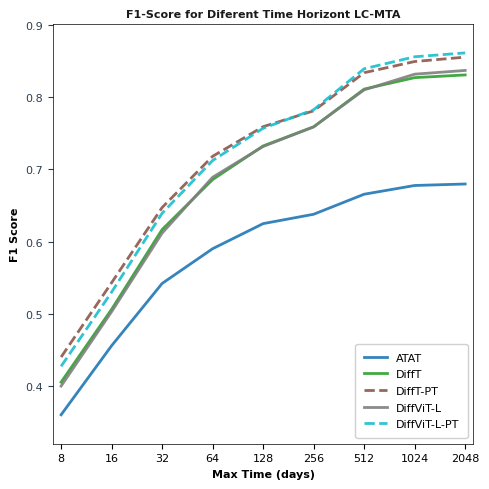

In [15]:
path_multimodal_lc = '../logs/eval/ATATPeriodicComparisonTTE_multimodal_LC.csv'
title_multimodal_lc = 'F1-Score for Diferent Time Horizont LC-MTA'
plot_f1_scores(
    path_multimodal_lc,
    title_multimodal_lc,
    architectures={'ATAT','DiffViT-L','DiffT'},
    save_path=os.path.join(output_dir, 'ATATPeriodicComparisonTTE_multimodal_LC.pdf')
)

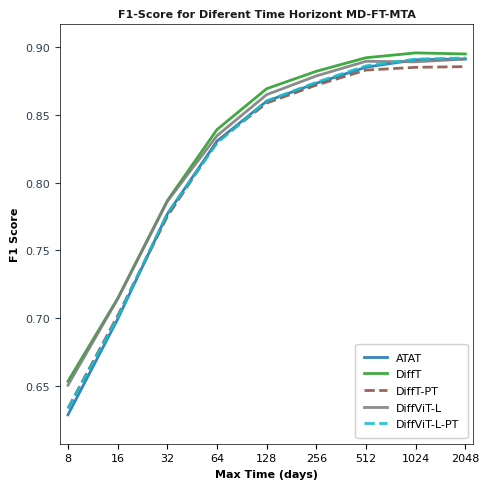

In [16]:
path_multimodal_feat = '../logs/eval/ATATPeriodicComparisonTTE_multimodal_Feat.csv'
title_multimodal_feat = 'F1-Score for Diferent Time Horizont MD-FT-MTA'
plot_f1_scores(
    path_multimodal_feat,
    title_multimodal_feat,
    architectures={'ATAT', 'DiffT', 'DiffViT-L'},
    save_path=os.path.join(output_dir, 'ATATPeriodicComparisonTTE_multimodal_Feat.pdf')
)

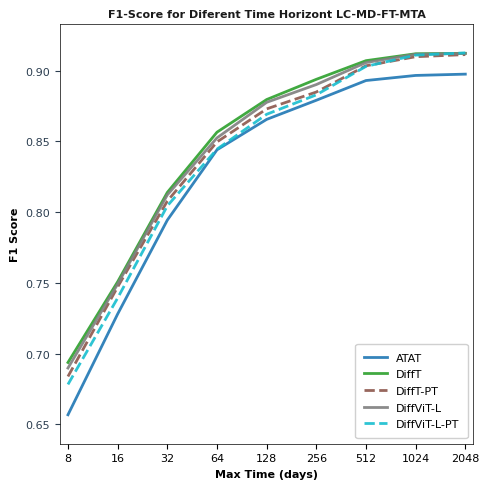

In [17]:
path_multimodal_mix = '../logs/eval/ATATPeriodicComparisonTTE_multimodal_Mix.csv'
title_multimodal_mix = 'F1-Score for Diferent Time Horizont LC-MD-FT-MTA'
plot_f1_scores(
    path_multimodal_mix,
    title_multimodal_mix,
    architectures={'ATAT','DiffViT-L','DiffT'},
    save_path=os.path.join(output_dir, 'ATATPeriodicComparisonTTE_multimodal_Mix.pdf')
)

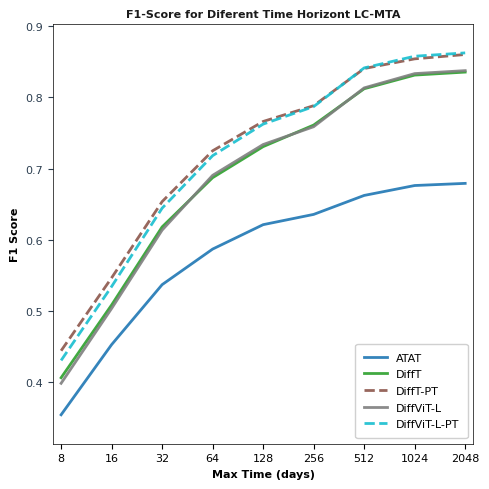

In [18]:
path_lcmd_lc = '../logs/eval/ATATPeriodicComparisonTTE_lc_md_LC.csv'
title_lcmd_lc = 'F1-Score for Diferent Time Horizont LC-MTA'
plot_f1_scores(
    path_lcmd_lc,
    title_lcmd_lc,
    architectures={'ATAT','DiffViT-L','DiffT'},
    save_path=os.path.join(output_dir, 'ATATPeriodicComparisonTTE_lc_md_LC.pdf')
)

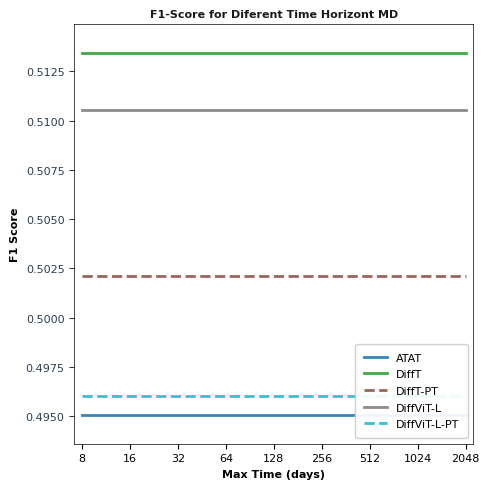

In [19]:
path_lcmd_feat = '../logs/eval/ATATPeriodicComparisonTTE_lc_md_Feat.csv'
title_lcmd_feat = 'F1-Score for Diferent Time Horizont MD'
plot_f1_scores(
    path_lcmd_feat,
    title_lcmd_feat,
    architectures={'ATAT','DiffViT-L','DiffT'},
    save_path=os.path.join(output_dir, 'ATATPeriodicComparisonTTE_lc_md_Feat.pdf')
)

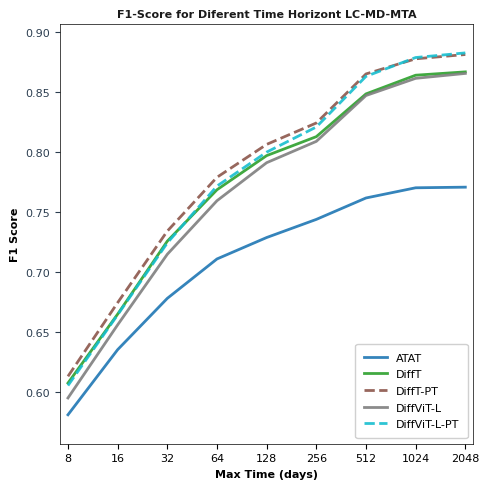

In [20]:
path_lcmd_mix = '../logs/eval/ATATPeriodicComparisonTTE_lc_md_Mix.csv'
title_lcmd_mix = 'F1-Score for Diferent Time Horizont LC-MD-MTA'
plot_f1_scores(
    path_lcmd_mix,
    title_lcmd_mix,
    architectures={'ATAT','DiffViT-L','DiffT'},
    save_path=os.path.join(output_dir, 'ATATPeriodicComparisonTTE_lc_md_Mix.pdf')
)